# Modeling Marketing Funnel Effects with `MuEffect`

This notebook shows how to extend PyMC-Marketing's `MMM` with a custom **`MuEffect`**
that models **mediation** between channels: upper-funnel spend builds awareness, which
lowers lower-funnel **CPM** (cost per mille), increases **impressions** for the same spend,
and ultimately drives sales.

We use **synthetic data** where the funnel mechanism is known, fit a **baseline MMM**
(all spend channels independent), then add a **`FunnelComponent`** and compare **ROAS**
estimates to ground truth.

For a full causal two-block treatment of upper funnel, see {ref}`mmm_upper_funnel_causal_approach`.
The real-data experiment draft lives in `mmm_marketing_funnel.py` (not in the gallery).

**Outline**

1. Synthetic data generating process (DGP)
2. Exploratory analysis
3. Causal DAG
4. Baseline MMM (spend-only channels)
5. `FunnelComponent` (`MuEffect`) and funnel MMM
6. ROAS comparison vs ground truth

In [1]:
from __future__ import annotations

import shutil
import warnings
from typing import Any

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc.dims as pmd
import seaborn as sns
import xarray as xr
from graphviz import Digraph
from IPython.display import Markdown, display
from pydantic import ConfigDict, Field
from pymc_extras.prior import Prior

from pymc_marketing.mmm import DelayedAdstock, GeometricAdstock, LogisticSaturation
from pymc_marketing.mmm.additive_effect import MuEffect
from pymc_marketing.mmm.mmm import MMM
from pymc_marketing.mmm.transformers import geometric_adstock, logistic_saturation
from pymc_marketing.special_priors import MaskedPrior

warnings.filterwarnings("ignore", category=FutureWarning)

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [12, 6]
plt.rcParams["figure.dpi"] = 100

seed: int = sum(map(ord, "mu_effect_funnel"))
rng: np.random.Generator = np.random.default_rng(seed=seed)

/home/teemu/miniforge3/envs/pymc-marketing-dev/lib/python3.12/site-packages/pymc/dims/__init__.py:66: UserWarning: The `pymc.dims` module is experimental and may contain critical bugs (p=0.064).
Please report any issues you encounter at https://github.com/pymc-devs/pymc/issues.
API changes are expected in future releases.

  __init__()
/home/teemu/miniforge3/envs/pymc-marketing-dev/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Channel roles

| Role | Channels |
|------|----------|
| Upper funnel | `TV`, `Radio`, `Social Media` |
| Lower funnel | `SEM` (spend), `SEM Impressions` (funnel model only) |
| Direct-only | `Direct Mail`, `Newspaper` |

In [2]:
UPPER_FUNNEL_CHANNELS: list[str] = ["TV", "Radio", "Social Media"]
LOWER_FUNNEL_CHANNEL: str = "SEM"
LOWER_FUNNEL_IMPRESSIONS: str = "SEM Impressions"
DIRECT_ONLY_CHANNELS: list[str] = ["Direct Mail", "Newspaper"]

BASELINE_CHANNEL_COLUMNS: list[str] = sorted(
    DIRECT_ONLY_CHANNELS + UPPER_FUNNEL_CHANNELS + [LOWER_FUNNEL_CHANNEL]
)
FUNNEL_CHANNEL_COLUMNS: list[str] = sorted(
    [*BASELINE_CHANNEL_COLUMNS, LOWER_FUNNEL_IMPRESSIONS]
)

DATE_COLUMN = "date"
TARGET_COLUMN = "sales"

## Synthetic DGP

**CPM definition:** `CPM = spend / impressions * 1000`, so `impressions = spend / CPM * 1000`.

Mechanism:

- Upper-funnel spend (summed, adstocked) reduces SEM CPM.
- SEM impressions follow from SEM spend and CPM.
- Sales get **direct** contributions from every spend channel plus a **mediated** path through impressions.
- `Direct Mail` and `Newspaper` only affect sales directly.

In [ ]:
def generate_funnel_mmm_data(
    n_weeks: int,
    *,
    rng: np.random.Generator,
    true_base_cpm: float = 8.0,
    true_max_cpm_reduction: float = 0.35,
    upper_adstock_alpha: float = 0.5,
    upper_adstock_l_max: int = 6,
    impression_beta: float = 1.2,
    impression_lam: float = 0.02,
) -> tuple[pd.DataFrame, dict[str, float]]:
    """Simulate weekly MMM panel with known funnel and direct-only channels."""
    dates = pd.date_range("2020-01-06", periods=n_weeks, freq="W-MON")
    n = n_weeks

    # Exogenous spends (positive, correlated over time)
    spends: dict[str, np.ndarray] = {}
    for channel in BASELINE_CHANNEL_COLUMNS:
        noise = rng.lognormal(mean=0.0, sigma=0.25, size=n)
        ar = np.zeros(n)
        for t in range(1, n):
            ar[t] = 0.7 * ar[t - 1] + noise[t]
        spends[channel] = 50_000 + 30_000 * np.exp(ar)

    upper_total = xr.DataArray(
        sum(spends[ch] for ch in UPPER_FUNNEL_CHANNELS), dims=DATE_COLUMN
    )
    upper_scaled = upper_total / upper_total.max()
    upper_adstocked = geometric_adstock(
        upper_scaled,
        alpha=upper_adstock_alpha,
        l_max=upper_adstock_l_max,
        normalize=True,
        dim=DATE_COLUMN,
    )
    cpm_effect = logistic_saturation(upper_adstocked, lam=1.5).eval()
    cpm = true_base_cpm * (1.0 - true_max_cpm_reduction * cpm_effect)
    cpm = np.clip(cpm, 0.5, None)

    sem_spend = spends[LOWER_FUNNEL_CHANNEL]
    sem_impressions = sem_spend / cpm * 1_000.0
    spends[LOWER_FUNNEL_IMPRESSIONS] = sem_impressions

    # Direct sales coefficients (per $1k spend after adstock)
    direct_betas: dict[str, float] = {
        "TV": 0.9,
        "Radio": 0.55,
        "Social Media": 0.7,
        "SEM": 0.15,  # small direct SEM effect; main lower-funnel path is mediated
        "Direct Mail": 0.45,
        "Newspaper": 0.35,
    }

    sales = 200_000.0 + 500.0 * np.arange(n, dtype=float)
    adstock_alpha = 0.4
    l_max = 6

    for channel, slope in direct_betas.items():
        adstocked = geometric_adstock(
            spends[channel] / 1_000.0,
            adstock_alpha,
            l_max,
            normalize=True,
            dim=DATE_COLUMN,
        )
        saturated = logistic_saturation(adstocked, lam=0.05)
        sales += slope * 1_000.0 * saturated

    imp_adstocked = geometric_adstock(
        sem_impressions / 1_000.0,
        adstock_alpha,
        l_max,
        normalize=True,
        dim=DATE_COLUMN,
    )
    imp_saturated = impression_beta * logistic_saturation(
        imp_adstocked, lam=impression_lam
    )
    sales += 2_000.0 * imp_saturated

    sales += rng.normal(0.0, 8_000.0, size=n)

    data_df = pd.DataFrame(
        {
            DATE_COLUMN: dates,
            TARGET_COLUMN: sales,
            **{ch: spends[ch] for ch in BASELINE_CHANNEL_COLUMNS},
            LOWER_FUNNEL_IMPRESSIONS: sem_impressions,
            "SEM_CPM": sem_spend / sem_impressions * 1_000.0,
        }
    )

    # Ground-truth ROAS: total incremental sales contribution / total spend
    true_contrib: dict[str, float] = {}
    for channel, slope in direct_betas.items():
        adstocked = geometric_adstock(spends[channel] / 1_000.0, adstock_alpha, l_max)
        saturated = logistic_saturation(adstocked, lam=0.05, beta=1.0)
        true_contrib[channel] = float((slope * 1_000.0 * saturated).sum())

    true_contrib[LOWER_FUNNEL_CHANNEL] = true_contrib.get(
        LOWER_FUNNEL_CHANNEL, 0.0
    ) + float((2_000.0 * imp_saturated).sum())

    true_roas = {
        ch: true_contrib[ch] / spends[ch].sum() for ch in BASELINE_CHANNEL_COLUMNS
    }
    return data_df, true_roas

In [14]:
N_WEEKS = 120
data_df, true_roas = generate_funnel_mmm_data(N_WEEKS, rng=rng)

X_baseline = data_df.drop(columns=[TARGET_COLUMN, "SEM_CPM", LOWER_FUNNEL_IMPRESSIONS])
X_funnel = data_df.drop(columns=[TARGET_COLUMN, "SEM_CPM"])
y = data_df[TARGET_COLUMN]

print(data_df[[DATE_COLUMN, TARGET_COLUMN, "SEM_CPM"]].head())
print("\nGround-truth ROAS (approximate from DGP):")
for ch, val in true_roas.items():
    print(f"  {ch:16s}: {val:.3f}")

TypeError: Cannot convert [  80.          106.23713492  170.50600374  207.4091632   366.10457014
  459.55437524  598.78789894  666.83408305  629.92771415  683.1062992
  863.25885798  639.78458304 1184.87585699  956.92207013  927.98454905
 1784.95579602 1535.78872343 1361.63414994 1056.9863206   945.20857069
  815.39493618  827.31284448  745.84225417  753.03587386  610.80907958
  598.88681502  626.62492477  837.47650508  956.07435515  757.83565756
  985.97506671  829.86083334 1200.36535804 1178.33685269  966.75748975
 1695.07878618 1212.73982218 1161.79017958 1336.47946926  982.14885575
  884.35341174  915.31096011  982.6021266   760.48748779 1022.88919819
  751.97508624  688.01866001  552.01991899  456.87009995  742.22678897
  799.70516266  849.40607216 1029.57434332  921.1281989  1111.83146384
  827.68662522  643.50257332  764.61653664 1530.08367589 1544.4309185
 1214.26667493 1540.83736061 1168.3232534  1346.06419158  928.84080618
 1124.54025723 1213.95635606 1142.98740667 1614.89387

## Exploratory analysis

By construction, higher upper-funnel activity should associate with **lower** SEM CPM.

/tmp/ipykernel_1676482/3372390314.py:17: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


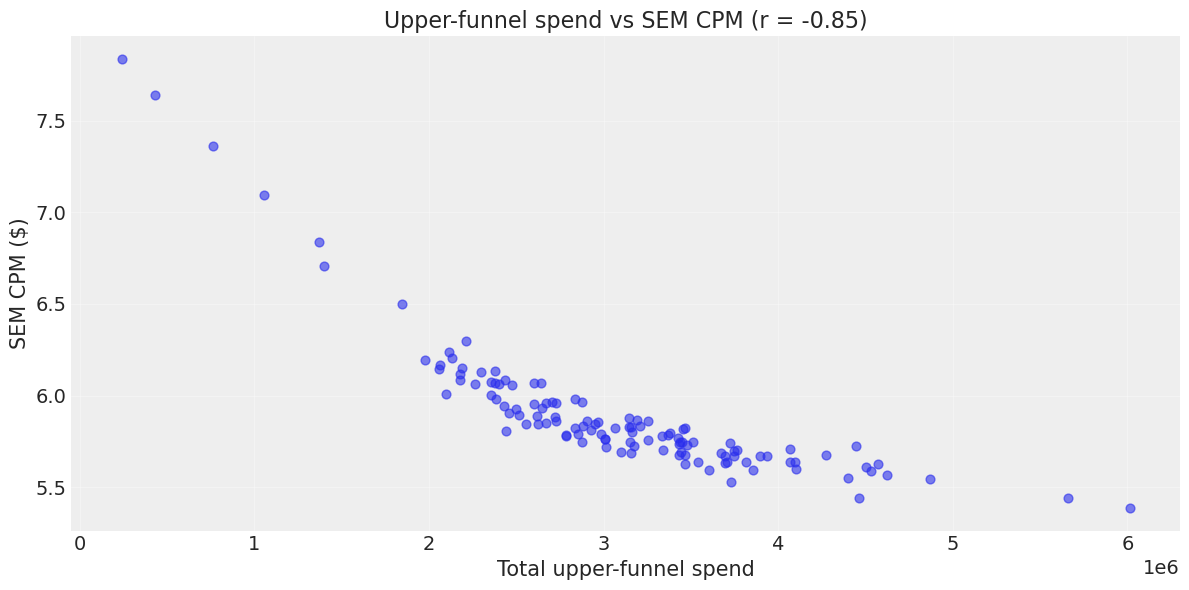

In [6]:
data_df["total_upper_funnel_spend"] = data_df[UPPER_FUNNEL_CHANNELS].sum(axis=1)
corr = data_df[["total_upper_funnel_spend", "SEM_CPM"]].corr().iloc[0, 1]

fig, ax = plt.subplots()
ax.scatter(
    data_df["total_upper_funnel_spend"],
    data_df["SEM_CPM"],
    alpha=0.6,
    s=40,
)
ax.set(
    xlabel="Total upper-funnel spend",
    ylabel="SEM CPM ($)",
    title=f"Upper-funnel spend vs SEM CPM (r = {corr:.2f})",
)
ax.grid(True, alpha=0.3)
plt.tight_layout()

## Causal DAG

Upper-funnel channels have **direct** paths to sales and an **indirect** path through SEM CPM and impressions.
Direct-only channels only touch sales.

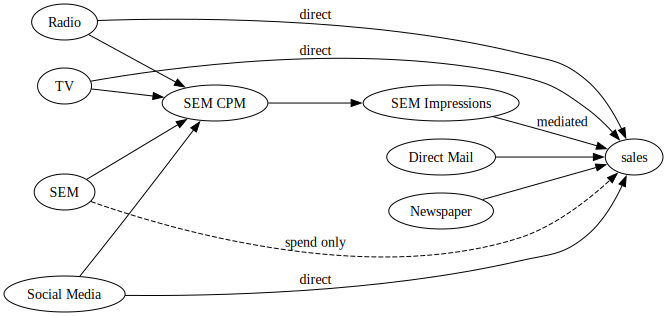

In [7]:
dag = Digraph("funnel_mmm_dag", format="png")
dag.attr(rankdir="LR")

for ch in UPPER_FUNNEL_CHANNELS:
    dag.node(ch, ch)
for ch in DIRECT_ONLY_CHANNELS:
    dag.node(ch, ch)
dag.node(LOWER_FUNNEL_CHANNEL, LOWER_FUNNEL_CHANNEL)
dag.node("cpm", "SEM CPM")
dag.node("imps", LOWER_FUNNEL_IMPRESSIONS)
dag.node(TARGET_COLUMN, TARGET_COLUMN)

for ch in UPPER_FUNNEL_CHANNELS:
    dag.edge(ch, TARGET_COLUMN, label="direct")
    dag.edge(ch, "cpm")
for ch in DIRECT_ONLY_CHANNELS:
    dag.edge(ch, TARGET_COLUMN)
dag.edge(LOWER_FUNNEL_CHANNEL, "cpm")
dag.edge("cpm", "imps")
dag.edge("imps", TARGET_COLUMN, label="mediated")
dag.edge(LOWER_FUNNEL_CHANNEL, TARGET_COLUMN, style="dashed", label="spend only")

# Render when Graphviz `dot` is available (CI/docs); otherwise show DOT source.
if shutil.which("dot"):
    display(dag)
else:
    display(Markdown(f"```dot\n{dag.source}\n```"))

## Shared model configuration

Simple channel-agnostic priors (no spend-share scaling).

In [8]:
def make_saturation(
    channel_columns: list[str],
    *,
    mask_direct_paths: set[str] | None = None,
) -> LogisticSaturation:
    """Logistic saturation with optional MaskedPrior on beta and lam."""
    if mask_direct_paths:
        mask = xr.DataArray(
            [ch not in mask_direct_paths for ch in channel_columns],
            dims=["channel"],
            coords={"channel": channel_columns},
        )
        return LogisticSaturation(
            priors={
                "beta": MaskedPrior(
                    Prior("HalfNormal", sigma=1.0, dims="channel"),
                    mask=mask,
                ),
                "lam": MaskedPrior(
                    Prior("Gamma", alpha=3, beta=1, dims="channel"),
                    mask=mask,
                ),
            }
        )
    return LogisticSaturation(
        priors={
            "beta": Prior("HalfNormal", sigma=1.0, dims="channel"),
            "lam": Prior("Gamma", alpha=3, beta=1, dims="channel"),
        }
    )


MODEL_CONFIG = {
    "intercept": Prior("Normal", mu=0.2, sigma=0.05),
    "adstock_alpha": Prior("Beta", alpha=1, beta=3, dims="channel"),
    "gamma_fourier": Prior("Laplace", mu=0, b=1),
    "likelihood": Prior("Normal", sigma=1.0),
}

SAMPLER_CONFIG = {"progressbar": True}
ADSTOCK = GeometricAdstock(
    l_max=6,
    priors={"alpha": Prior("Beta", alpha=1, beta=3, dims="channel")},
)

FIT_KWARGS = {
    "target_accept": 0.9,
    "chains": 4,
    "draws": 400,
    "tune": 800,
    "nuts_sampler": "nutpie",
    "random_seed": rng,
}

## Baseline MMM

All **spend** channels enter the standard media transform independently (including `SEM`).
No `SEM Impressions` column.

In [9]:
mmm_baseline = MMM(
    model_config=MODEL_CONFIG,
    sampler_config=SAMPLER_CONFIG,
    date_column=DATE_COLUMN,
    channel_columns=BASELINE_CHANNEL_COLUMNS,
    target_column=TARGET_COLUMN,
    adstock=ADSTOCK,
    saturation=make_saturation(BASELINE_CHANNEL_COLUMNS),
    yearly_seasonality=3,
)

mmm_baseline.build_model(X_baseline, y)
mmm_baseline.add_original_scale_contribution_variable(
    var=["channel_contribution", "y"],
)
mmm_baseline.fit(X=X_baseline, y=y, **FIT_KWARGS)
mmm_baseline.sample_posterior_predictive(X=X_baseline, random_seed=rng)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,1200,0,0.22,15
,1200,0,0.26,15
,1200,0,0.24,15
,1200,0,0.25,15


/home/teemu/miniforge3/envs/pymc-marketing-dev/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling: [y]


/home/teemu/miniforge3/envs/pymc-marketing-dev/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

<xarray.Dataset> Size: 3MB
Dimensions:           (date: 120, sample: 1600)
Coordinates:
  * date              (date) datetime64[ns] 960B 2020-01-06 ... 2022-04-18
  * sample            (sample) object 13kB MultiIndex
  * chain             (sample) int64 13kB 0 0 0 0 0 0 0 0 0 ... 3 3 3 3 3 3 3 3
  * draw              (sample) int64 13kB 0 1 2 3 4 5 ... 395 396 397 398 399
Data variables:
    y                 (date, sample) float64 2MB 0.3081 0.5486 ... -0.4018
    y_original_scale  (date, sample) float64 2MB 8.675e+04 ... -1.131e+05
Attributes:
    created_at:                 2026-06-03T08:23:58.031914+00:00
    arviz_version:              0.23.4
    inference_library:          pymc
    inference_library_version:  5.28.5

## `FunnelComponent`: a custom `MuEffect`

The component reads upper-funnel activity from `channel_data`, models CPM and impressions,
links model-implied impressions to observed `SEM Impressions` via a funnel likelihood, and adds
`funnel_contribution`
to the linear predictor.

Lower-funnel **`SEM`** and **`SEM Impressions`** have their direct `channel_contribution`
paths masked out; upper-funnel and direct-only channels keep direct paths.

In [10]:
class FunnelComponent(MuEffect):
    """Upper-funnel awareness lowers lower-funnel CPM and drives mediated sales.

    Observed lower-funnel impressions are tied to ``spend / CPM * 1000`` via
    ``funnel_impressions_likelihood``.
    """

    model_config = ConfigDict(arbitrary_types_allowed=True)

    lower_funnel_spend: str
    lower_funnel_impressions: str
    funnel_impressions_likelihood: Any = Field(exclude=True)
    upper_funnel_channels: list[str]
    saturation_upper_to_cpm: Any = Field(exclude=True)
    saturation_impressions: Any = Field(exclude=True)
    adstock_impressions: Any = Field(exclude=True)
    adstock_upper_funnel: Any = Field(exclude=True)
    base_cpm_prior: Any = Field(exclude=True)
    max_cpm_reduction_prior: Any = Field(exclude=True)

    @property
    def contribution_var_name(self) -> str:
        """Posterior variable name for the mediated funnel contribution."""
        return "funnel_contribution"

    def create_data(self, mmm: MMM) -> None:
        """No extra pm.Data; uses core MMM channel_data."""

    def create_effect(self, mmm: MMM):
        """Build CPM, impressions, and funnel_contribution deterministics."""
        model = mmm.model
        channel_data = model["channel_data"]
        channel_scale = model["channel_scale"]
        channel_data_scaled = channel_data / channel_scale

        channel_coords = list(model.coords["channel"])
        upper_idx = [channel_coords.index(ch) for ch in self.upper_funnel_channels]
        spend_idx = channel_coords.index(self.lower_funnel_spend)
        imp_idx = channel_coords.index(self.lower_funnel_impressions)

        upper_data = channel_data_scaled.isel(channel=upper_idx)
        total_upper = upper_data.sum(dim="channel")

        upper_adstocked = self.adstock_upper_funnel.apply(total_upper, core_dim="date")
        cpm_effect = self.saturation_upper_to_cpm.apply(
            upper_adstocked, core_dim="date"
        )

        base_cpm = self.base_cpm_prior.create_variable("funnel_base_cpm")
        max_cpm_reduction = self.max_cpm_reduction_prior.create_variable(
            "max_cpm_reduction"
        )
        cpm = pmd.Deterministic(
            "funnel_cpm",
            base_cpm * (1.0 - cpm_effect * max_cpm_reduction),
        )

        lower_spend = channel_data.isel(channel=spend_idx)
        obs_impressions = channel_data.isel(channel=imp_idx)
        imp_scale = channel_scale.isel(channel=imp_idx)

        impressions = pmd.Deterministic(
            "funnel_impressions",
            lower_spend / (cpm + 1e-6) * 1_000.0,
        )

        self.funnel_impressions_likelihood.create_likelihood_variable(
            "funnel_impressions_likelihood",
            mu=impressions / imp_scale,
            observed=obs_impressions / imp_scale,
            xdist=True,
        )

        impressions_scaled = impressions / imp_scale
        impressions_adstocked = self.adstock_impressions.apply(
            impressions_scaled, core_dim="date"
        )
        contribution = self.saturation_impressions.apply(
            impressions_adstocked, core_dim="date"
        )
        return pmd.Deterministic("funnel_contribution", contribution)

    def set_data(self, mmm: MMM, model, X: xr.Dataset) -> None:
        """OOS updates flow through MMM set_data on channel_data."""

## Funnel MMM

Same priors as baseline, plus `FunnelComponent` on the linear predictor.

In [11]:
LOWER_FUNNEL_MASK = {LOWER_FUNNEL_CHANNEL, LOWER_FUNNEL_IMPRESSIONS}

mmm_funnel = MMM(
    model_config=MODEL_CONFIG,
    sampler_config=SAMPLER_CONFIG,
    date_column=DATE_COLUMN,
    channel_columns=FUNNEL_CHANNEL_COLUMNS,
    target_column=TARGET_COLUMN,
    adstock=ADSTOCK,
    saturation=make_saturation(
        FUNNEL_CHANNEL_COLUMNS,
        mask_direct_paths=LOWER_FUNNEL_MASK,
    ),
    yearly_seasonality=3,
)

funnel_effect = FunnelComponent(
    lower_funnel_spend=LOWER_FUNNEL_CHANNEL,
    lower_funnel_impressions=LOWER_FUNNEL_IMPRESSIONS,
    funnel_impressions_likelihood=Prior("TruncatedNormal", lower=0, sigma=0.1),
    upper_funnel_channels=UPPER_FUNNEL_CHANNELS,
    saturation_upper_to_cpm=LogisticSaturation(
        prefix="funnel_cpm_sat",
        priors={
            "beta": Prior("HalfNormal", sigma=1.0),
            "lam": Prior("Gamma", alpha=3, beta=1),
        },
    ),
    saturation_impressions=LogisticSaturation(
        prefix="funnel_imp_sat",
        priors={
            "beta": Prior("HalfNormal", sigma=1.0),
            "lam": Prior("Gamma", alpha=3, beta=1),
        },
    ),
    adstock_impressions=GeometricAdstock(
        l_max=3,
        prefix="funnel_imp_adstock",
        priors={"alpha": Prior("Beta", alpha=3, beta=1)},
    ),
    adstock_upper_funnel=DelayedAdstock(
        l_max=6,
        prefix="funnel_upper_adstock",
        priors={
            "alpha": Prior("Beta", alpha=1, beta=3),
            "theta": Prior("HalfNormal", sigma=1.0),
        },
    ),
    base_cpm_prior=Prior("HalfNormal", sigma=10.0),
    max_cpm_reduction_prior=Prior("Beta", alpha=5, beta=5),
)

mmm_funnel.add_mu_effect(funnel_effect)
mmm_funnel.build_model(X_funnel, y)
mmm_funnel.add_original_scale_contribution_variable(
    var=["channel_contribution", "y"],
)
mmm_funnel.fit(X=X_funnel, y=y, **FIT_KWARGS)
mmm_funnel.sample_posterior_predictive(X=X_funnel, random_seed=rng)

/tmp/ipykernel_1676482/64811080.py:15: UserWarning: This class is experimental and its API may change in future versions.
  "beta": MaskedPrior(
/tmp/ipykernel_1676482/64811080.py:19: UserWarning: This class is experimental and its API may change in future versions.
  "lam": MaskedPrior(


Progress,Draws,Divergences,Step Size,Gradients/Draw
,1200,6,0.15,31
,1200,2,0.17,31
,1200,8,0.14,31
,1200,4,0.18,31


/home/teemu/miniforge3/envs/pymc-marketing-dev/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling: [funnel_impressions_likelihood, y]


/home/teemu/miniforge3/envs/pymc-marketing-dev/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

<xarray.Dataset> Size: 5MB
Dimensions:                        (date: 120, sample: 1600)
Coordinates:
  * date                           (date) datetime64[ns] 960B 2020-01-06 ... ...
  * sample                         (sample) object 13kB MultiIndex
  * chain                          (sample) int64 13kB 0 0 0 0 0 0 ... 3 3 3 3 3
  * draw                           (sample) int64 13kB 0 1 2 3 ... 397 398 399
Data variables:
    y                              (date, sample) float64 2MB 0.4629 ... -0.9096
    funnel_impressions_likelihood  (date, sample) float64 2MB 0.08217 ... 0.0...
    y_original_scale               (date, sample) float64 2MB 1.304e+05 ... -...
Attributes:
    created_at:                 2026-06-03T08:24:35.641615+00:00
    arviz_version:              0.23.4
    inference_library:          pymc
    inference_library_version:  5.28.5

### Diagnostics (funnel model)

In [12]:
print(f"Divergences: {int(mmm_funnel.idata['sample_stats']['diverging'].sum())}")

Divergences: 20


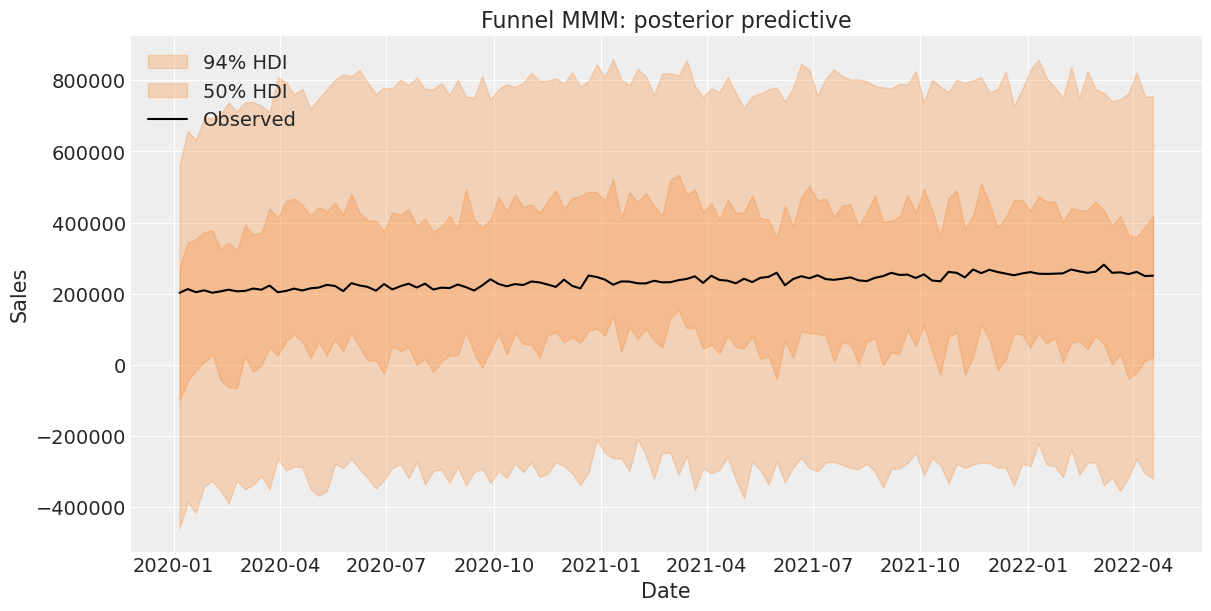

In [13]:
fig, ax = plt.subplots()
for hdi_prob in (0.94, 0.5):
    az.plot_hdi(
        x=mmm_funnel.model.coords["date"],
        y=mmm_funnel.idata["posterior_predictive"].y_original_scale,
        hdi_prob=hdi_prob,
        smooth=False,
        fill_kwargs={"alpha": 0.25, "label": f"{hdi_prob:.0%} HDI"},
        ax=ax,
    )
sns.lineplot(
    data=data_df, x=DATE_COLUMN, y=TARGET_COLUMN, color="black", ax=ax, label="Observed"
)
ax.set(title="Funnel MMM: posterior predictive", xlabel="Date", ylabel="Sales")
ax.legend(loc="upper left")

### Funnel quantities

Use `posterior["funnel_contribution"]` directly (not a residual of `mu`).

[Text(0, 0.5, 'Sales contribution'),
 Text(0.5, 0, 'Date'),
 Text(0.5, 1.0, 'Lower-funnel mediated path')]

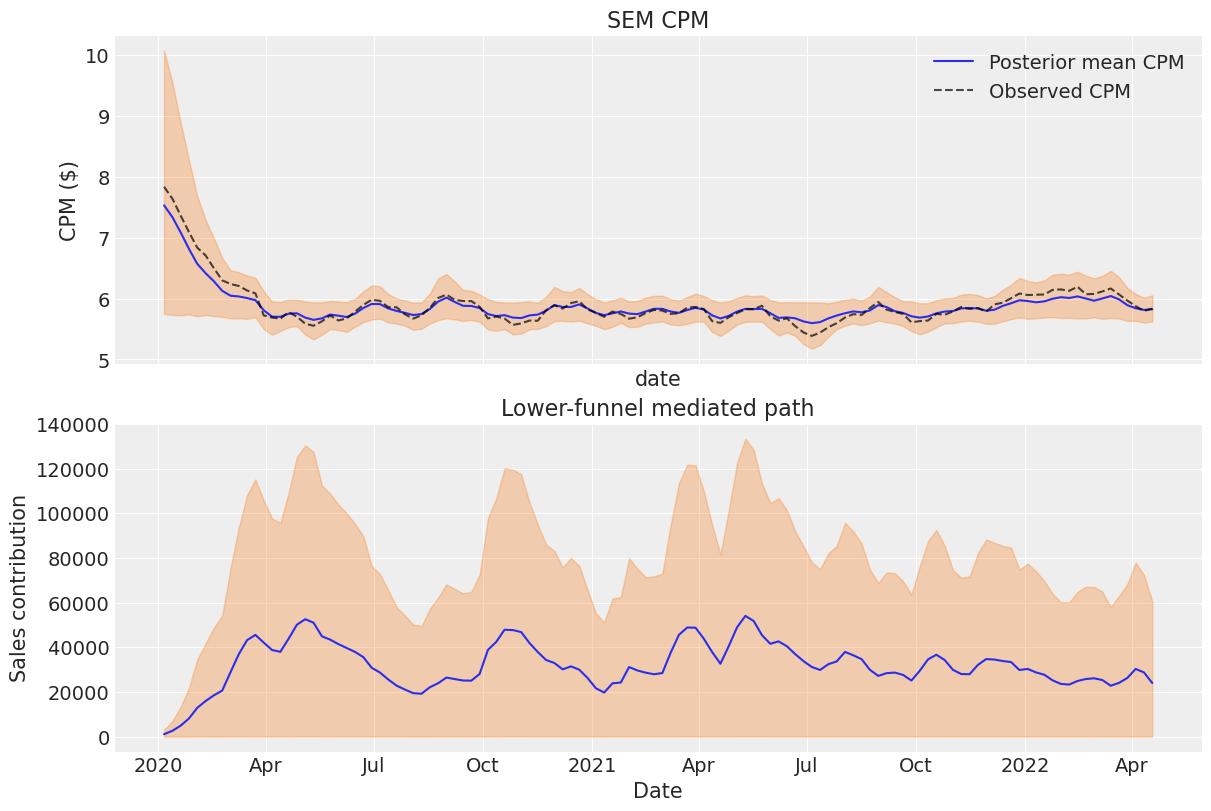

In [15]:
funnel_contrib = mmm_funnel.idata["posterior"]["funnel_contribution"]
target_scale = mmm_funnel.idata["constant_data"]["target_scale"].values

fig, axes = plt.subplots(2, 1, figsize=(12, 8), layout="constrained", sharex=True)

cpm_post = mmm_funnel.idata["posterior"]["funnel_cpm"]
az.plot_hdi(
    mmm_funnel.model.coords["date"],
    cpm_post,
    hdi_prob=0.94,
    smooth=False,
    ax=axes[0],
    fill_kwargs={"alpha": 0.3},
)
cpm_post.mean(["chain", "draw"]).plot(ax=axes[0], label="Posterior mean CPM")
axes[0].plot(
    data_df[DATE_COLUMN], data_df["SEM_CPM"], "k--", alpha=0.7, label="Observed CPM"
)
axes[0].set(ylabel="CPM ($)", title="SEM CPM")
axes[0].legend()

funnel_sales = funnel_contrib * target_scale
az.plot_hdi(
    mmm_funnel.model.coords["date"],
    funnel_sales,
    hdi_prob=0.94,
    smooth=False,
    ax=axes[1],
    fill_kwargs={"alpha": 0.3},
)
funnel_sales.mean(["chain", "draw"]).plot(ax=axes[1], label="Mediated SEM contribution")
axes[1].set(
    ylabel="Sales contribution", xlabel="Date", title="Lower-funnel mediated path"
)

## ROAS comparison

ROAS = sum of contribution over time / sum of spend (all-time, posterior mean).

In [16]:
def posterior_roas_channel(
    mmm: MMM,
    X: pd.DataFrame,
    channels: list[str],
) -> pd.Series:
    """ROAS from channel_contribution_original_scale when available."""
    post = mmm.idata["posterior"]
    if "channel_contribution_original_scale" in post:
        contrib = post["channel_contribution_original_scale"].sum("date")
    else:
        scale = float(mmm.idata["constant_data"]["target_scale"].values)
        contrib = post["channel_contribution"].sum("date") * scale
    contrib_mean = contrib.mean(["chain", "draw"])
    spend = X[channels].sum()
    return contrib_mean.to_pandas().divide(spend)


def posterior_roas_funnel(mmm: MMM, X: pd.DataFrame) -> float:
    """ROAS for mediated lower-funnel path."""
    post = mmm.idata["posterior"]
    scale = mmm.idata["constant_data"]["target_scale"]
    contrib = post["funnel_contribution"].sum("date").mean(["chain", "draw"]) * scale
    spend = X[LOWER_FUNNEL_CHANNEL].sum()
    return contrib.values / spend

In [17]:
roas_baseline = posterior_roas_channel(
    mmm_baseline, X_baseline, BASELINE_CHANNEL_COLUMNS
)
roas_funnel_direct = posterior_roas_channel(
    mmm_funnel, X_funnel, BASELINE_CHANNEL_COLUMNS
)
roas_funnel_mediated = posterior_roas_funnel(mmm_funnel, X_funnel)

comparison = pd.DataFrame(
    {
        "true_roas": pd.Series(true_roas),
        "baseline_roas": roas_baseline,
        "funnel_direct_roas": roas_funnel_direct.reindex(BASELINE_CHANNEL_COLUMNS),
    }
)
comparison["funnel_total_sem_roas"] = np.nan
comparison.loc[LOWER_FUNNEL_CHANNEL, "funnel_total_sem_roas"] = (
    roas_funnel_direct.get(LOWER_FUNNEL_CHANNEL, 0.0) + roas_funnel_mediated
)
comparison

,true_roas,baseline_roas,funnel_direct_roas,funnel_total_sem_roas
Direct Mail,0.000484,0.032430,0.034228,NaN
Newspaper,0.000339,0.029819,0.030197,NaN
Radio,0.000558,0.032628,0.032593,NaN
SEM,0.002575,0.033977,0.000000,0.032301
Social Media,0.000701,0.029906,0.029112,NaN
TV,0.000843,0.029007,0.027115,NaN


Text(0.5, 0.98, 'ROAS: posterior mean vs synthetic ground truth')

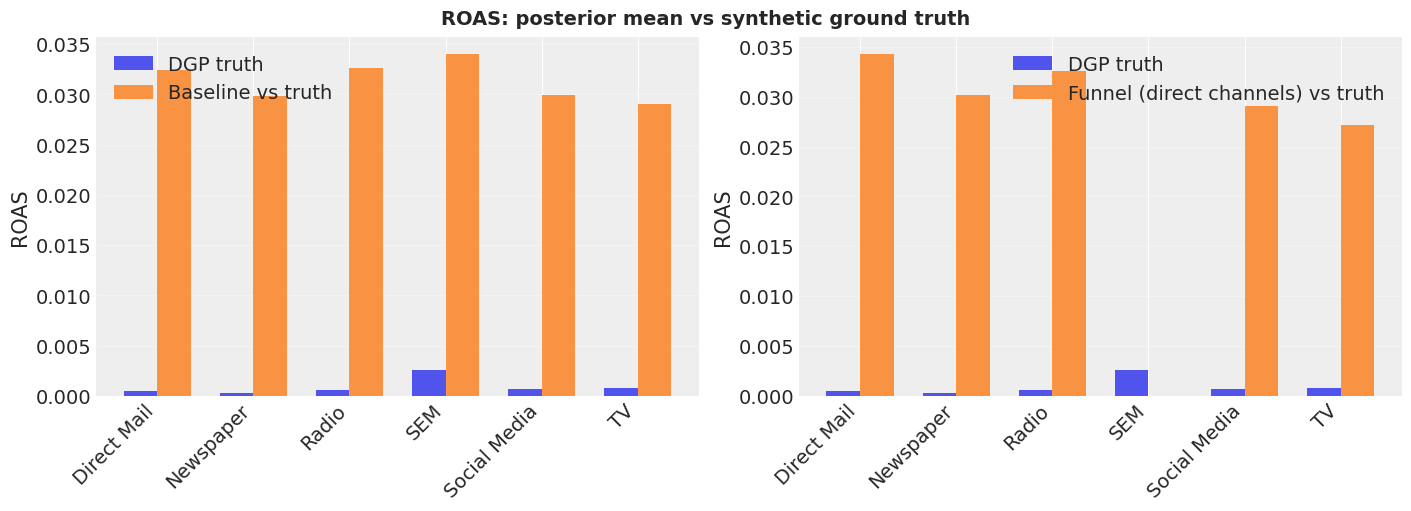

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), layout="constrained")

for ax, (label, series, _ref) in zip(
    axes,
    [
        ("Baseline vs truth", roas_baseline, true_roas),
        (
            "Funnel (direct channels) vs truth",
            roas_funnel_direct,
            true_roas,
        ),
    ],
    strict=True,
):
    channels = list(BASELINE_CHANNEL_COLUMNS)
    x = np.arange(len(channels))
    width = 0.35
    est = [float(series.get(c, np.nan)) for c in channels]
    tru = [true_roas[c] for c in channels]
    ax.bar(x - width / 2, tru, width, label="DGP truth", alpha=0.8)
    ax.bar(x + width / 2, est, width, label=label, alpha=0.8)
    ax.set_xticks(x, channels, rotation=45, ha="right")
    ax.set_ylabel("ROAS")
    ax.legend()
    ax.grid(True, axis="y", alpha=0.3)

fig.suptitle(
    "ROAS: posterior mean vs synthetic ground truth", fontsize=14, fontweight="bold"
)

## Takeaways

- **`MuEffect`** adds structured components to the MMM linear predictor without forking the core class.
- **`FunnelComponent`** encodes mediation: upper-funnel → CPM → impressions → sales, with `SEM` / `SEM Impressions`
  kept in `channel_data` for easy OOS updates while **masking** their direct media paths.
- **Baseline vs funnel:** baseline attributes all `SEM` effect to a single channel curve; the funnel model
  separates **direct** upper-funnel effects from the **mediated** SEM path and usually changes upper-funnel ROAS.
- **Synthetic data** is essential for teaching: real panels (see `mmm_marketing_funnel.py`) often lack
  a clear upper-funnel → CPM signal.
- **Next steps:** partial pooling over geos, multiple lower-funnel channels, or the full causal workflow
  in {ref}`mmm_upper_funnel_causal_approach`.